In [1]:
!pip install timm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import timm
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


1. 

In [2]:
# ===================== CONFIG =====================
BATCH_SIZE = 128
EPOCHS = 20   # increased
LR = 3e-4
NUM_CLASSES = 30
EPS = 1e-8

selected_classes = list(range(NUM_CLASSES))


In [3]:
# ===================== TRANSFORMS =====================
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
])



In [4]:
# ===================== DATASET FILTER =====================
def filter_dataset(dataset, selected_classes):
    targets = np.array(dataset.targets)
    mask = np.isin(targets, selected_classes)

    dataset.data = dataset.data[mask]
    dataset.targets = targets[mask].tolist()

    # Remap labels → [0, NUM_CLASSES-1]
    label_map = {cls: i for i, cls in enumerate(selected_classes)}
    dataset.targets = [label_map[t] for t in dataset.targets]

    return dataset


In [5]:
# ===================== DATA =====================
train_dataset = torchvision.datasets.CIFAR100(
    root="./data", train=True, download=True, transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR100(
    root="./data", train=False, download=True, transform=transform_test
)

train_dataset = filter_dataset(train_dataset, selected_classes)
test_dataset = filter_dataset(test_dataset, selected_classes)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

100%|██████████| 169M/169M [00:02<00:00, 59.7MB/s] 


In [6]:
import timm
import torch.nn as nn

model = timm.create_model('vit_base_patch16_224', pretrained=True)

in_features = model.head.in_features
model.head = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Using 2 GPUs


In [7]:
# # ===================== FEATURE EXTRACTION =====================
# def get_cls_features(model, x):
#     model.eval()
#     with torch.no_grad():
#         x = model.patch_embed(x)
#         cls_token = model.cls_token.expand(x.shape[0], -1, -1)
#         x = torch.cat((cls_token, x), dim=1)
#         x = model.pos_drop(x + model.pos_embed)

#         for blk in model.blocks:
#             x = blk(x)

#         x = model.norm(x)
#         cls_features = x[:, 0]

#     return cls_features


In [8]:
def get_cls_features(model, x):
    model.eval()
    
    m = model.module if hasattr(model, "module") else model
    
    with torch.no_grad():
        x = m.patch_embed(x)
        cls_token = m.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = m.pos_drop(x + m.pos_embed)

        for blk in m.blocks:
            x = blk(x)

        x = m.norm(x)
        cls_features = x[:, 0]

    return cls_features

In [9]:
# ===================== NC METRICS =====================
def compute_nc_metrics(features, labels, classifier_weights):
    features = features.cpu().numpy()
    labels = labels.cpu().numpy()
    W = classifier_weights.detach().cpu().numpy()

    K = len(np.unique(labels))

    class_means = []
    for k in range(K):
        class_k = features[labels == k]
        mu_k = np.mean(class_k, axis=0)
        class_means.append(mu_k)

    class_means = np.array(class_means)
    overall_mean = np.mean(features, axis=0)

    # NC1
    Sw = 0.0
    for k in range(K):
        class_k = features[labels == k]
        mu_k = class_means[k]
        Sw += np.sum((class_k - mu_k) ** 2)

    Sb = np.sum((class_means - overall_mean) ** 2)
    nc1 = Sw / (Sb + EPS)

    # NC2
    M = class_means - overall_mean
    M = M / (np.linalg.norm(M, axis=1, keepdims=True) + EPS)
    G = M @ M.T

    ETF = np.full((K, K), -1/(K-1))
    np.fill_diagonal(ETF, 1)

    nc2 = np.linalg.norm(G - ETF, ord='fro')

    # NC3
    W_norm = W / (np.linalg.norm(W, axis=1, keepdims=True) + EPS)
    nc3 = np.linalg.norm(W_norm - M, ord='fro')

    return nc1, nc2, nc3


In [10]:
# ===================== FLATNESS =====================
def compute_relative_flatness(features, logits, labels, classifier_weights):
    probs = torch.softmax(logits, dim=1)
    p_y = probs[torch.arange(len(labels)), labels]

    curvature_term = p_y * (1 - p_y)
    feat_norm_sq = torch.sum(features**2, dim=1)

    trace_estimate = torch.mean(feat_norm_sq * curvature_term)

    weight_norm_sq = torch.sum(classifier_weights**2)

    return (trace_estimate / (weight_norm_sq + EPS)).item()


In [11]:
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 15000
Test size: 3000


In [12]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR)

In [13]:
# ===================== TRACKERS =====================
nc1_hist, nc2_hist, nc3_hist = [], [], []
flatness_hist = []

train_acc_hist, test_acc_hist = [], []

train_f1_macro_hist, test_f1_macro_hist = [], []
train_f1_weighted_hist, test_f1_weighted_hist = [], []


In [14]:
# ===================== TRAIN LOOP =====================
for epoch in range(EPOCHS):

    # -------- TRAIN --------
    model.train()
    train_preds, train_labels_all = [], []
    total_loss = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [TRAIN]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels_all.extend(labels.cpu().numpy())

    train_acc = np.mean(np.array(train_preds) == np.array(train_labels_all)) * 100
    print(f"\nTrain Loss: {total_loss:.4f}")
    print(f"Train Acc: {train_acc:.2f}%")

    # -------- TEST (ONLY ACCURACY NOW) -------- 🔴 CHANGE
    model.eval()
    test_preds, test_labels_all = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1} [TEST]"):
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            preds = logits.argmax(dim=1)

            test_preds.extend(preds.cpu().numpy())
            test_labels_all.extend(labels.cpu().numpy())

    test_acc = np.mean(np.array(test_preds) == np.array(test_labels_all)) * 100
    print(f"Test Acc: {test_acc:.2f}%")

    # -------- NC + FLATNESS ON TRAIN -------- 🔴 CHANGE (major fix)
    model.eval()
    all_features, all_labels, all_logits = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [NC-TRAIN]"):
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            feats = get_cls_features(model, images)

            all_features.append(feats)
            all_labels.append(labels)
            all_logits.append(logits)

    all_features = torch.cat(all_features)
    all_labels = torch.cat(all_labels)
    all_logits = torch.cat(all_logits)

    nc1, nc2, nc3 = compute_nc_metrics(
        all_features,
        all_labels,
        model.module.head.weight   # 🔴 CHANGE (DataParallel safe)
    )

    flatness = compute_relative_flatness(
        all_features,
        all_logits,
        all_labels,
        model.module.head.weight   # 🔴 CHANGE
    )

    print(f"NC1: {nc1:.6f} | NC2: {nc2:.6f} | NC3: {nc3:.6f}")
    print(f"Flatness: {flatness:.6f}")

Epoch 1 [TRAIN]: 100%|██████████| 118/118 [04:21<00:00,  2.22s/it]



Train Loss: 390.7946
Train Acc: 8.09%


Epoch 1 [TEST]: 100%|██████████| 24/24 [00:20<00:00,  1.20it/s]


Test Acc: 9.03%


Epoch 1 [NC-TRAIN]: 100%|██████████| 118/118 [04:16<00:00,  2.17s/it]


...


Train Loss: 18.4709
Train Acc: 94.67%


Epoch 20 [TEST]: 100%|██████████| 24/24 [00:20<00:00,  1.20it/s]


Test Acc: 63.93%


Epoch 20 [NC-TRAIN]: 100%|██████████| 118/118 [04:21<00:00,  2.22s/it]


NC1: 727.626465 | NC2: 6.117205 | NC3: 3.278613
Flatness: 5.752725


In [15]:
for epoch in range(EPOCHS, EPOCHS + 10):

    # -------- TRAIN --------
    model.train()
    train_preds, train_labels_all = [], []
    total_loss = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [TRAIN]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels_all.extend(labels.cpu().numpy())

    train_acc = np.mean(np.array(train_preds) == np.array(train_labels_all)) * 100
    print(f"\nTrain Loss: {total_loss:.4f}")
    print(f"Train Acc: {train_acc:.2f}%")

    # -------- TEST (ONLY ACCURACY NOW) -------- 🔴 CHANGE
    model.eval()
    test_preds, test_labels_all = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1} [TEST]"):
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            preds = logits.argmax(dim=1)

            test_preds.extend(preds.cpu().numpy())
            test_labels_all.extend(labels.cpu().numpy())

    test_acc = np.mean(np.array(test_preds) == np.array(test_labels_all)) * 100
    print(f"Test Acc: {test_acc:.2f}%")

    # -------- NC + FLATNESS ON TRAIN -------- 🔴 CHANGE (major fix)
    model.eval()
    all_features, all_labels, all_logits = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [NC-TRAIN]"):
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            feats = get_cls_features(model, images)

            all_features.append(feats)
            all_labels.append(labels)
            all_logits.append(logits)

    all_features = torch.cat(all_features)
    all_labels = torch.cat(all_labels)
    all_logits = torch.cat(all_logits)

    nc1, nc2, nc3 = compute_nc_metrics(
        all_features,
        all_labels,
        model.module.head.weight   # 🔴 CHANGE (DataParallel safe)
    )

    flatness = compute_relative_flatness(
        all_features,
        all_logits,
        all_labels,
        model.module.head.weight   # 🔴 CHANGE
    )

    print(f"NC1: {nc1:.6f} | NC2: {nc2:.6f} | NC3: {nc3:.6f}")
    print(f"Flatness: {flatness:.6f}")

Epoch 21 [TRAIN]: 100%|██████████| 118/118 [04:37<00:00,  2.35s/it]



Train Loss: 15.5699
Train Acc: 95.40%


Epoch 21 [TEST]: 100%|██████████| 24/24 [00:20<00:00,  1.18it/s]


Test Acc: 64.23%


Epoch 21 [NC-TRAIN]: 100%|██████████| 118/118 [04:19<00:00,  2.20s/it]


...


Train Loss: 8.1171
Train Acc: 97.68%


Epoch 30 [TEST]: 100%|██████████| 24/24 [00:20<00:00,  1.19it/s]


Test Acc: 65.33%


Epoch 30 [NC-TRAIN]: 100%|██████████| 118/118 [04:21<00:00,  2.22s/it]


NC1: 736.763245 | NC2: 5.507859 | NC3: 3.125641
Flatness: 3.429125


In [18]:
epochs = list(range(1, 31))

train_loss_hist = [
    390.7946, 320.3354, 263.5310, 231.0104, 198.7420,
    172.1036, 146.7558, 126.9745, 106.0628, 87.2047,
    74.6760, 59.7336, 49.7018, 41.9527, 33.1979,
    27.5983, 25.6759, 19.7778, 16.4936, 18.4709,
    15.5699, 12.4668, 12.6885, 9.5114, 8.6724,
    13.3741, 11.8735, 11.3680, 8.9283, 8.1171
]

train_acc_hist = [
    8.09, 22.39, 35.02, 42.25, 49.70,
    56.11, 61.94, 66.23, 71.47, 76.03,
    79.29, 83.41, 86.21, 87.78, 90.39,
    92.16, 92.65, 94.35, 95.39, 94.67,
    95.40, 96.26, 96.42, 97.21, 97.64,
    96.21, 96.63, 96.83, 97.49, 97.68
]

test_acc_hist = [
    9.03, 26.73, 40.10, 42.23, 51.67,
    54.17, 57.00, 58.67, 61.47, 60.90,
    61.70, 63.83, 62.80, 64.87, 63.07,
    62.87, 63.53, 62.87, 64.17, 63.93,
    64.23, 65.03, 64.63, 63.70, 65.30,
    65.63, 63.53, 64.57, 63.73, 65.33
]

nc1_hist = [
    1353.255127, 983.760437, 816.409180, 809.232544, 797.998596,
    785.876404, 750.849976, 720.783691, 703.529602, 733.438171,
    722.523682, 753.907043, 762.612061, 757.175354, 756.018433,
    780.904663, 771.308777, 750.076172, 723.463562, 727.626465,
    738.361938, 754.807251, 744.407410, 721.380676, 723.343079,
    727.633362, 735.298523, 701.863403, 716.527893, 736.763245
]

nc2_hist = [
    16.461665, 13.682690, 13.453971, 11.538902, 10.064473,
    9.846479, 9.417275, 9.446543, 8.784865, 7.956737,
    8.081516, 7.905972, 7.516217, 7.076618, 6.899069,
    6.688651, 6.771031, 6.814021, 6.481826, 6.117205,
    6.083577, 6.039265, 5.915322, 5.906507, 5.852648,
    6.143454, 5.967046, 5.712376, 5.460657, 5.507859
]

nc3_hist = [
    6.550463, 5.833080, 5.320792, 4.928198, 4.597984,
    4.413946, 4.212910, 4.070197, 3.938233, 3.843869,
    3.764836, 3.746183, 3.666485, 3.506628, 3.451592,
    3.422100, 3.451547, 3.385912, 3.312595, 3.278613,
    3.243990, 3.242546, 3.220000, 3.169797, 3.151927,
    3.211193, 3.228974, 3.111514, 3.112013, 3.125641
]

flatness_hist = [
    1.398780, 5.674242, 7.217570, 8.529166, 8.984435,
    9.476940, 10.121478, 10.797409, 12.072779, 13.055220,
    12.374022, 12.792050, 11.866646, 10.041356, 9.818291,
    9.729294, 8.859440, 8.609495, 6.227723, 5.752725,
    5.618926, 5.701217, 5.530098, 4.843488, 4.376653,
    4.460642, 4.490637, 3.118221, 4.175365, 3.429125
]

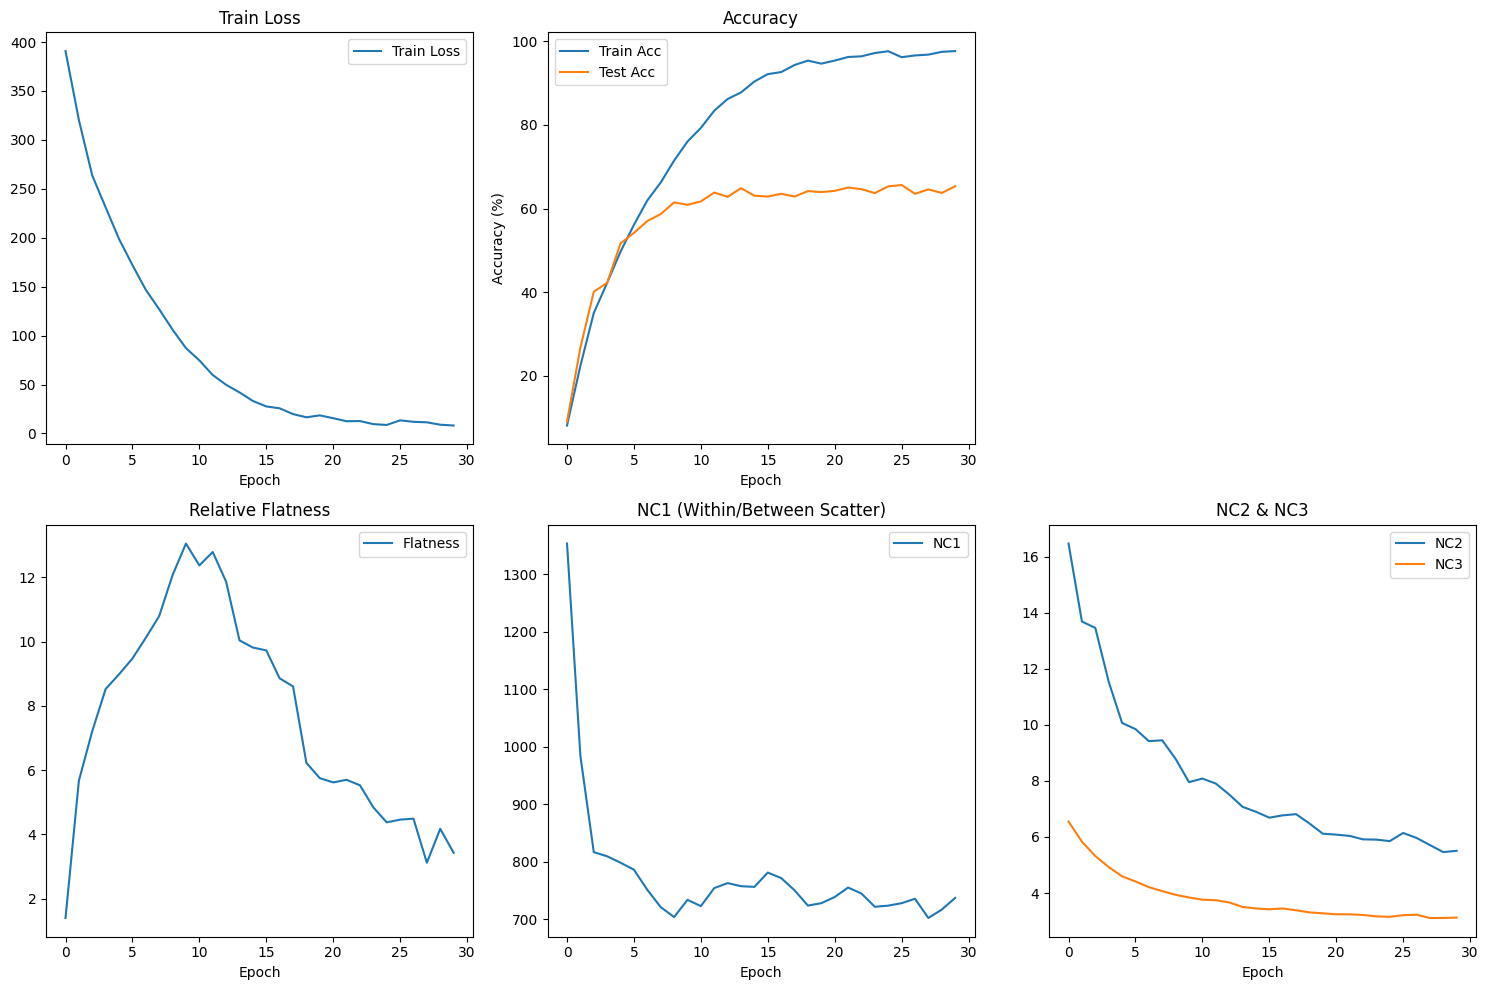

In [20]:
plt.figure(figsize=(15,10))

# -------- Accuracy --------
plt.subplot(2,3,2)
plt.plot(train_acc_hist, label="Train Acc")
plt.plot(test_acc_hist, label="Test Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

# -------- F1 Macro --------
plt.subplot(2,3,1)
plt.plot(train_loss_hist, label="Train Loss")
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.legend()

# # -------- F1 Weighted --------
# plt.subplot(2,3,3)
# plt.plot(train_f1_weighted_hist, label="Train F1 Weighted")
# plt.plot(test_f1_weighted_hist, label="Test F1 Weighted")
# plt.title("F1 Weighted")
# plt.xlabel("Epoch")
# plt.legend()

# -------- Flatness --------
plt.subplot(2,3,4)
plt.plot(flatness_hist, label="Flatness")
plt.title("Relative Flatness")
plt.xlabel("Epoch")
plt.legend()

# -------- NC1 --------
plt.subplot(2,3,5)
plt.plot(nc1_hist, label="NC1")
plt.title("NC1 (Within/Between Scatter)")
plt.xlabel("Epoch")
plt.legend()

# -------- NC2 & NC3 --------
plt.subplot(2,3,6)
plt.plot(nc2_hist, label="NC2")
plt.plot(nc3_hist, label="NC3")
plt.title("NC2 & NC3")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()